In [32]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, HTML

from plot_style_utils import (
    apply_plot_theme,
    plot_ratio_distribution,
    plot_annotated_bar,
    display_summary_table,
    save_plot_data,
    PALETTE,
)

# =========================
# USER SETTINGS
# =========================
DATA_DIR = Path("../prof_components_extracted")

MIN_YEAR = 2005
MAX_YEAR = 2024

# Revenue filter
MIN_REVENUE = 1.0

# Flagging thresholds for cost_ratio = (COGS + XSGA_COMPONENTS) / REVT
LOW_THRESHOLD = 0.40
HIGH_THRESHOLD = 1.20

# Optional: extreme thresholds for quick diagnostics
EXTREME_LOW_THRESHOLD = 0.15
EXTREME_HIGH_THRESHOLD = 2.00

# Plot settings
TOP_N_EXCHANGES = 15
TOP_N_SECTORS = 15

# Plot export settings
PLOT_VERSION = "baseline"

PLOTS_DIR = Path("plots") / PLOT_VERSION
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

SAVED_FIGURES = []

def register_figure(fig, name):
    SAVED_FIGURES.append((fig, name))
    return fig

def save_all_registered_plots(figures=None, output_dir=None, close_after_save=False):
    figures = SAVED_FIGURES if figures is None else figures
    output_dir = PLOTS_DIR if output_dir is None else Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    saved = []
    for fig, name in figures:
        filepath = output_dir / f"{name}.png"
        fig.savefig(filepath, dpi=300, bbox_inches="tight")
        saved.append(filepath)

    print(f"Saved {len(saved)} plots to: {output_dir.resolve()}")
    for fp in saved:
        print(" -", fp.name)

    if close_after_save:
        for fig, _ in figures:
            plt.close(fig)

if not DATA_DIR.exists():
    raise FileNotFoundError(f"Data folder not found: {DATA_DIR.resolve()}")

apply_plot_theme()

print("Using data from:", DATA_DIR.resolve())
print("Plots will be saved to:", PLOTS_DIR.resolve())


Using data from: /Users/fredrikfuglerudflugstad/Library/Mobile Documents/com~apple~CloudDocs/Skole/NTNU/Industriell Økonomi og Teknologiledelse/10. Semester/Equity_Quality_Under_Uncertainty/PROF/prof_components_extracted
Plots will be saved to: /Users/fredrikfuglerudflugstad/Library/Mobile Documents/com~apple~CloudDocs/Skole/NTNU/Industriell Økonomi og Teknologiledelse/10. Semester/Equity_Quality_Under_Uncertainty/PROF/data_analysis/plots/baseline


In [33]:
rows = []
bad_files = []

for fp in sorted(DATA_DIR.glob("*.csv")):
    try:
        df = pd.read_csv(fp)
    except Exception as e:
        bad_files.append((fp.name, f"read_error: {e}"))
        continue

    if "Year" not in df.columns:
        bad_files.append((fp.name, "missing Year"))
        continue

    df["Year"] = pd.to_numeric(df["Year"], errors="coerce")
    df = df.dropna(subset=["Year"]).copy()
    df["Year"] = df["Year"].astype(int)
    df = df[(df["Year"] >= MIN_YEAR) & (df["Year"] <= MAX_YEAR)].copy()

    if df.empty:
        continue

    # fallback identifiers
    if "Ticker" not in df.columns:
        df["Ticker"] = fp.stem
    if "firm" not in df.columns:
        df["firm"] = fp.stem

    rows.append(df)

if not rows:
    raise ValueError("No valid CSV files were loaded.")

panel = pd.concat(rows, ignore_index=True)

print(f"Loaded rows: {len(panel):,}")
print(f"Unique tickers: {panel['Ticker'].nunique():,}")

if bad_files:
    print("\nSkipped files:")
    for name, reason in bad_files[:20]:
        print(f"- {name}: {reason}")

Loaded rows: 9,774
Unique tickers: 635


In [34]:
required_cols = ["REVT", "COGS", "XSGA_COMPONENTS"]
missing_required = [c for c in required_cols if c not in panel.columns]
if missing_required:
    raise ValueError(f"Missing required columns: {missing_required}")

for col in required_cols:
    panel[col] = pd.to_numeric(panel[col], errors="coerce")

panel["COGS_filled"] = panel["COGS"].fillna(0.0)
panel["XSGA_filled"] = panel["XSGA_COMPONENTS"].fillna(0.0)

panel["REVT_valid"] = panel["REVT"].notna() & (panel["REVT"] > MIN_REVENUE)
panel["TOTAL_COST_PROXY"] = panel["COGS_filled"] + panel["XSGA_filled"]

panel["cost_ratio"] = np.where(
    panel["REVT_valid"],
    panel["TOTAL_COST_PROXY"] / panel["REVT"],
    np.nan
)

# Diagnostics
panel["flag_low"] = panel["cost_ratio"] < LOW_THRESHOLD
panel["flag_high"] = panel["cost_ratio"] > HIGH_THRESHOLD
panel["flag_extreme_low"] = panel["cost_ratio"] < EXTREME_LOW_THRESHOLD
panel["flag_extreme_high"] = panel["cost_ratio"] > EXTREME_HIGH_THRESHOLD

panel["flag_any"] = panel["REVT_valid"] & (panel["flag_low"] | panel["flag_high"])

In [35]:
summary = panel[["cost_ratio"]].describe()
print(summary)

print("\nThresholds used:")
print(f"LOW_THRESHOLD         = {LOW_THRESHOLD}")
print(f"HIGH_THRESHOLD        = {HIGH_THRESHOLD}")
print(f"EXTREME_LOW_THRESHOLD = {EXTREME_LOW_THRESHOLD}")
print(f"EXTREME_HIGH_THRESHOLD= {EXTREME_HIGH_THRESHOLD}")
print(f"MIN_REVENUE           = {MIN_REVENUE}")

n_total = len(panel)
n_valid = panel["REVT_valid"].sum()
n_flagged = panel["flag_any"].sum()
n_low = panel["flag_low"].sum()
n_high = panel["flag_high"].sum()

print("\nCounts:")
print(f"Total rows           : {n_total:,}")
print(f"Valid ratio rows     : {n_valid:,}")
print(f"Flagged rows         : {n_flagged:,}")
print(f"Low flagged          : {n_low:,}")
print(f"High flagged         : {n_high:,}")

if n_valid > 0:
    print(f"Flagged / valid      : {n_flagged / n_valid:.2%}")
    print(f"Low / valid          : {n_low / n_valid:.2%}")
    print(f"High / valid         : {n_high / n_valid:.2%}")

        cost_ratio
count  9365.000000
mean      1.241527
std       3.622107
min       0.000000
25%       0.742612
50%       0.889859
75%       0.962535
max     106.531661

Thresholds used:
LOW_THRESHOLD         = 0.4
HIGH_THRESHOLD        = 1.2
EXTREME_LOW_THRESHOLD = 0.15
EXTREME_HIGH_THRESHOLD= 2.0
MIN_REVENUE           = 1.0

Counts:
Total rows           : 9,774
Valid ratio rows     : 9,365
Flagged rows         : 1,757
Low flagged          : 741
High flagged         : 1,016
Flagged / valid      : 18.76%
Low / valid          : 7.91%
High / valid         : 10.85%


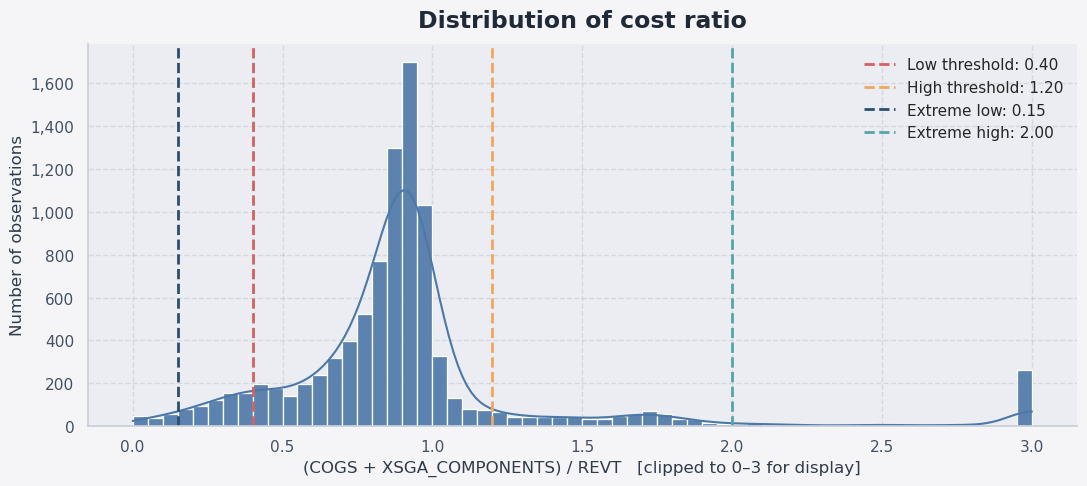

In [36]:
plot_data = panel.loc[panel["cost_ratio"].notna(), "cost_ratio"]

fig, ax = plot_ratio_distribution(
    plot_data,
    low_threshold=LOW_THRESHOLD,
    high_threshold=HIGH_THRESHOLD,
    extreme_low=EXTREME_LOW_THRESHOLD,
    extreme_high=EXTREME_HIGH_THRESHOLD,
)

register_figure(fig, "cost_ratio_distribution")
plt.show()
plt.close(fig)


In [37]:
def extract_exchange(ticker):
    if pd.isna(ticker):
        return "Unknown"
    ticker = str(ticker)
    if "." in ticker:
        return ticker.split(".")[-1]
    return "Unknown"

panel["Exchange"] = panel["Ticker"].apply(extract_exchange)

/Users/fredrikfuglerudflugstad/Library/Mobile Documents/com~apple~CloudDocs/Skole/NTNU/Industriell Økonomi og Teknologiledelse/10. Semester/Equity_Quality_Under_Uncertainty/PROF/data_analysis/plot_style_utils.py:113: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(s.index.astype(str), rotation=rotation, ha="right" if rotation else "center")


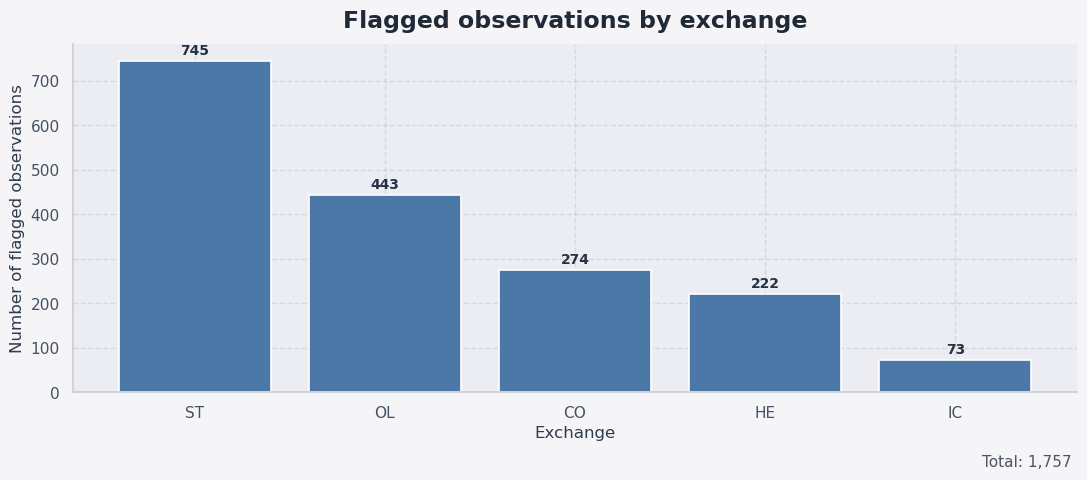

/Users/fredrikfuglerudflugstad/Library/Mobile Documents/com~apple~CloudDocs/Skole/NTNU/Industriell Økonomi og Teknologiledelse/10. Semester/Equity_Quality_Under_Uncertainty/PROF/data_analysis/plot_style_utils.py:113: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(s.index.astype(str), rotation=rotation, ha="right" if rotation else "center")


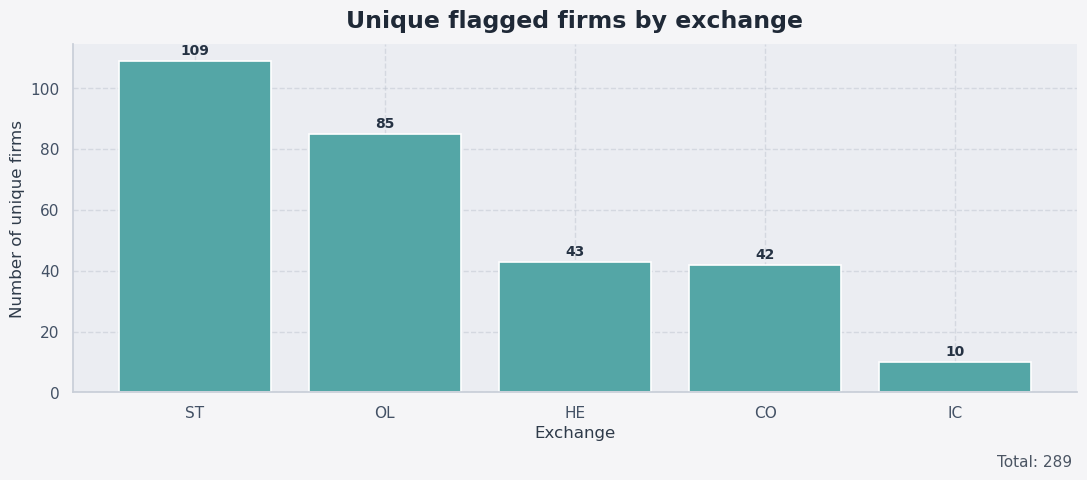

,Exchange,flagged_observations,unique_flagged_firms
0,ST,745,109
1,OL,443,85
2,CO,274,42
3,HE,222,43
4,IC,73,10


In [38]:
flagged = panel.loc[panel["flag_any"]].copy()

exchange_obs = (
    flagged.groupby("Exchange")
    .size()
    .sort_values(ascending=False)
    .head(TOP_N_EXCHANGES)
)

exchange_firms = (
    flagged.groupby("Exchange")["Ticker"]
    .nunique()
    .sort_values(ascending=False)
    .head(TOP_N_EXCHANGES)
)

fig, ax = plot_annotated_bar(
    exchange_obs,
    title="Flagged observations by exchange",
    xlabel="Exchange",
    ylabel="Number of flagged observations",
    color=PALETTE["blue"],
    top_n=TOP_N_EXCHANGES,
    rotation=0,
)
register_figure(fig, "flagged_observations_by_exchange")

fig, ax = plot_annotated_bar(
    exchange_firms,
    title="Unique flagged firms by exchange",
    xlabel="Exchange",
    ylabel="Number of unique firms",
    color=PALETTE["teal"],
    top_n=TOP_N_EXCHANGES,
    rotation=0,
)
register_figure(fig, "unique_flagged_firms_by_exchange")

exchange_counts = (
    pd.DataFrame({
        "Exchange": exchange_obs.index,
        "flagged_observations": exchange_obs.values,
        "unique_flagged_firms": exchange_firms.reindex(exchange_obs.index).fillna(0).astype(int).values,
    })
)

save_plot_data("exchange_counts", exchange_counts)
display(exchange_counts)


/Users/fredrikfuglerudflugstad/Library/Mobile Documents/com~apple~CloudDocs/Skole/NTNU/Industriell Økonomi og Teknologiledelse/10. Semester/Equity_Quality_Under_Uncertainty/PROF/data_analysis/plot_style_utils.py:113: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(s.index.astype(str), rotation=rotation, ha="right" if rotation else "center")


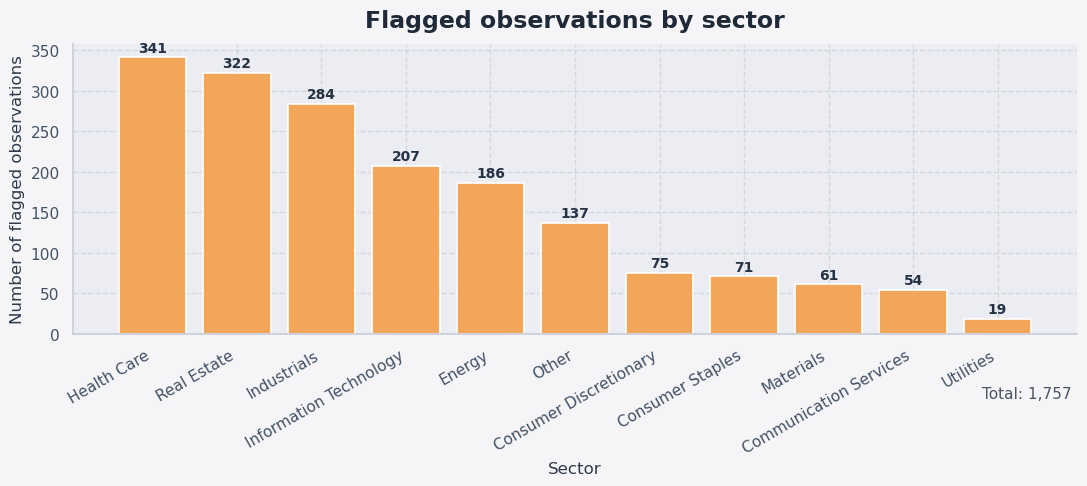

/Users/fredrikfuglerudflugstad/Library/Mobile Documents/com~apple~CloudDocs/Skole/NTNU/Industriell Økonomi og Teknologiledelse/10. Semester/Equity_Quality_Under_Uncertainty/PROF/data_analysis/plot_style_utils.py:113: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(s.index.astype(str), rotation=rotation, ha="right" if rotation else "center")


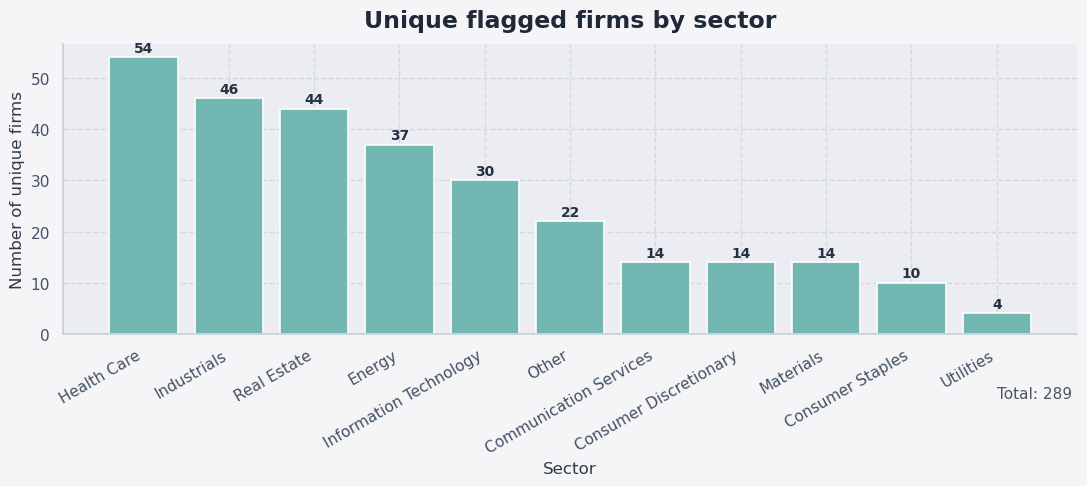

,Sector,flagged_observations,unique_flagged_firms
0,Health Care,341,54
1,Real Estate,322,44
2,Industrials,284,46
3,Information Technology,207,30
4,Energy,186,37
5,Other,137,22
6,Consumer Discretionary,75,14
7,Consumer Staples,71,10
8,Materials,61,14
9,Communication Services,54,14


In [39]:
if "Sector" in flagged.columns:
    sector_obs = (
        flagged.groupby("Sector")
        .size()
        .sort_values(ascending=False)
        .head(TOP_N_SECTORS)
    )

    sector_firms = (
        flagged.groupby("Sector")["Ticker"]
        .nunique()
        .sort_values(ascending=False)
        .head(TOP_N_SECTORS)
    )

    fig, ax = plot_annotated_bar(
        sector_obs,
        title="Flagged observations by sector",
        xlabel="Sector",
        ylabel="Number of flagged observations",
        color=PALETTE["orange"],
        top_n=TOP_N_SECTORS,
        rotation=30,
    )
    register_figure(fig, "flagged_observations_by_sector")

    fig, ax = plot_annotated_bar(
        sector_firms,
        title="Unique flagged firms by sector",
        xlabel="Sector",
        ylabel="Number of unique firms",
        color=PALETTE["green"],
        top_n=TOP_N_SECTORS,
        rotation=30,
    )
    register_figure(fig, "unique_flagged_firms_by_sector")

    sector_counts = (
        pd.DataFrame({
            "Sector": sector_obs.index,
            "flagged_observations": sector_obs.values,
            "unique_flagged_firms": sector_firms.reindex(sector_obs.index).fillna(0).astype(int).values,
        })
    )

    save_plot_data("sector_counts", sector_counts)
    display(sector_counts)
else:
    print("Column 'Sector' not found.")


In [40]:
summary = panel[["cost_ratio"]].describe()
print(summary)

print("\nThresholds used:")
print(f"LOW_THRESHOLD          = {LOW_THRESHOLD}")
print(f"HIGH_THRESHOLD         = {HIGH_THRESHOLD}")
print(f"EXTREME_LOW_THRESHOLD  = {EXTREME_LOW_THRESHOLD}")
print(f"EXTREME_HIGH_THRESHOLD = {EXTREME_HIGH_THRESHOLD}")
print(f"MIN_REVENUE            = {MIN_REVENUE}")

n_total = len(panel)
n_valid = panel["REVT_valid"].sum()
n_flagged = panel["flag_any"].sum()
n_low = panel["flag_low"].sum()
n_high = panel["flag_high"].sum()

n_unique_firms_total = panel["Ticker"].nunique()
n_unique_firms_valid = panel.loc[panel["REVT_valid"], "Ticker"].nunique()
n_unique_firms_flagged = panel.loc[panel["flag_any"], "Ticker"].nunique()

print("\nCounts:")
print(f"Total rows             : {n_total:,}")
print(f"Valid ratio rows       : {n_valid:,}")
print(f"Flagged rows           : {n_flagged:,}")
print(f"  Low flagged          : {n_low:,}")
print(f"  High flagged         : {n_high:,}")
print(f"Unique firms total     : {n_unique_firms_total:,}")
print(f"Unique firms valid     : {n_unique_firms_valid:,}")
print(f"Unique firms flagged   : {n_unique_firms_flagged:,}")


        cost_ratio
count  9365.000000
mean      1.241527
std       3.622107
min       0.000000
25%       0.742612
50%       0.889859
75%       0.962535
max     106.531661

Thresholds used:
LOW_THRESHOLD          = 0.4
HIGH_THRESHOLD         = 1.2
EXTREME_LOW_THRESHOLD  = 0.15
EXTREME_HIGH_THRESHOLD = 2.0
MIN_REVENUE            = 1.0

Counts:
Total rows             : 9,774
Valid ratio rows       : 9,365
Flagged rows           : 1,757
  Low flagged          : 741
  High flagged         : 1,016
Unique firms total     : 635
Unique firms valid     : 627
Unique firms flagged   : 289


In [41]:
flag_summary = pd.DataFrame({
    "metric": [
        "Total rows",
        "Valid ratio rows",
        "Flagged rows",
        "Low flagged rows",
        "High flagged rows",
        "Unique firms total",
        "Unique firms valid",
        "Unique firms flagged",
    ],
    "value": [
        len(panel),
        panel["REVT_valid"].sum(),
        panel["flag_any"].sum(),
        panel["flag_low"].sum(),
        panel["flag_high"].sum(),
        panel["Ticker"].nunique(),
        panel.loc[panel["REVT_valid"], "Ticker"].nunique(),
        panel.loc[panel["flag_any"], "Ticker"].nunique(),
    ],
})

save_plot_data("flag_summary", flag_summary)
display_summary_table(flag_summary)


metric,value
Total rows,"9,774"
Valid ratio rows,"9,365"
Flagged rows,"1,757"
Low flagged rows,741
High flagged rows,"1,016"
Unique firms total,635
Unique firms valid,627
Unique firms flagged,289


/Users/fredrikfuglerudflugstad/Library/Mobile Documents/com~apple~CloudDocs/Skole/NTNU/Industriell Økonomi og Teknologiledelse/10. Semester/Equity_Quality_Under_Uncertainty/PROF/data_analysis/plot_style_utils.py:113: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(s.index.astype(str), rotation=rotation, ha="right" if rotation else "center")


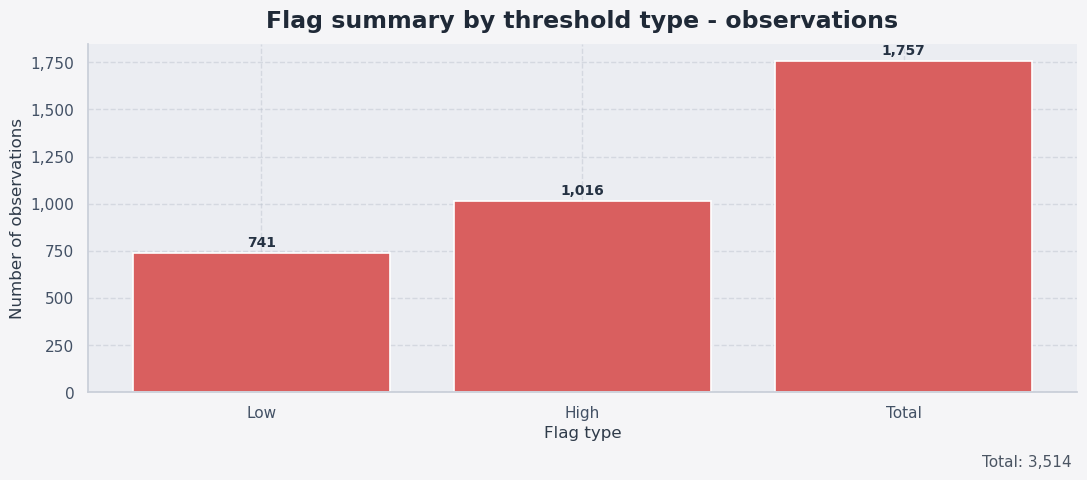

/Users/fredrikfuglerudflugstad/Library/Mobile Documents/com~apple~CloudDocs/Skole/NTNU/Industriell Økonomi og Teknologiledelse/10. Semester/Equity_Quality_Under_Uncertainty/PROF/data_analysis/plot_style_utils.py:113: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(s.index.astype(str), rotation=rotation, ha="right" if rotation else "center")


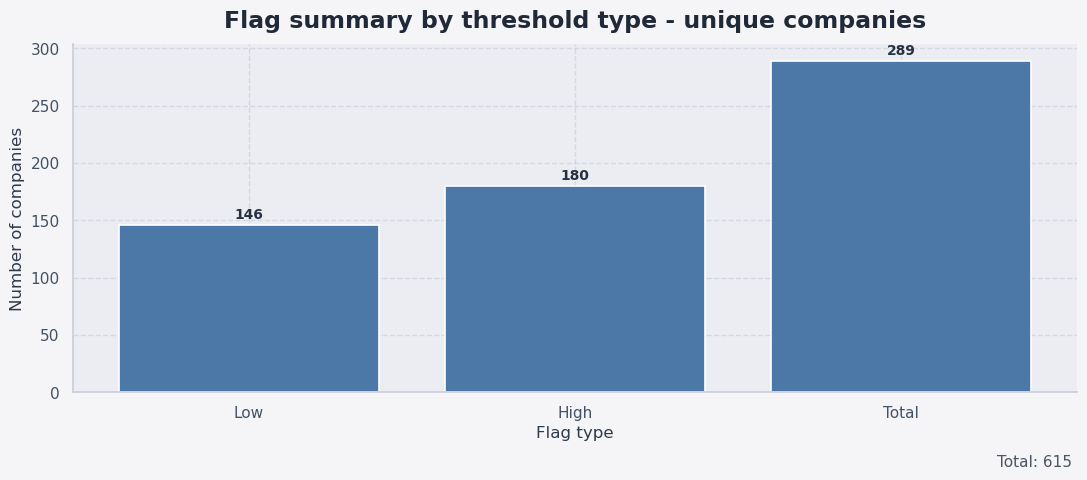

PosixPath('plot_exports/flag_type_counts.parquet')

In [42]:
flag_type_counts = pd.DataFrame({
    "flag_type": ["Low", "High", "Total"],
    "observations": [
        int(panel["flag_low"].sum()),
        int(panel["flag_high"].sum()),
        int(panel["flag_any"].sum()),
    ],
    "unique_companies": [
        panel.loc[panel["flag_low"], "Ticker"].nunique(),
        panel.loc[panel["flag_high"], "Ticker"].nunique(),
        panel.loc[panel["flag_any"], "Ticker"].nunique(),
    ]
}).set_index("flag_type")

flag_type_counts


fig_obs, ax_obs = plot_annotated_bar(
    flag_type_counts["observations"],
    title="Flag summary by threshold type - observations",
    xlabel="Flag type",
    ylabel="Number of observations",
    color=PALETTE["red"],
    rotation=0,
)
register_figure(fig_obs, "flag_summary_observations")
plt.show()

fig_comp, ax_comp = plot_annotated_bar(
    flag_type_counts["unique_companies"],
    title="Flag summary by threshold type - unique companies",
    xlabel="Flag type",
    ylabel="Number of companies",
    color=PALETTE["blue"],
    rotation=0,
)
register_figure(fig_comp, "flag_summary_unique_companies")
plt.show()

save_plot_data(
    "flag_type_counts",
    flag_type_counts.reset_index()
)

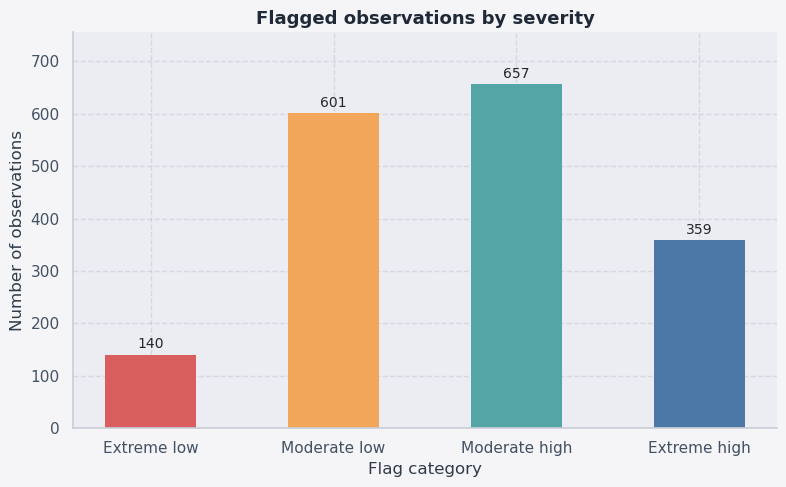

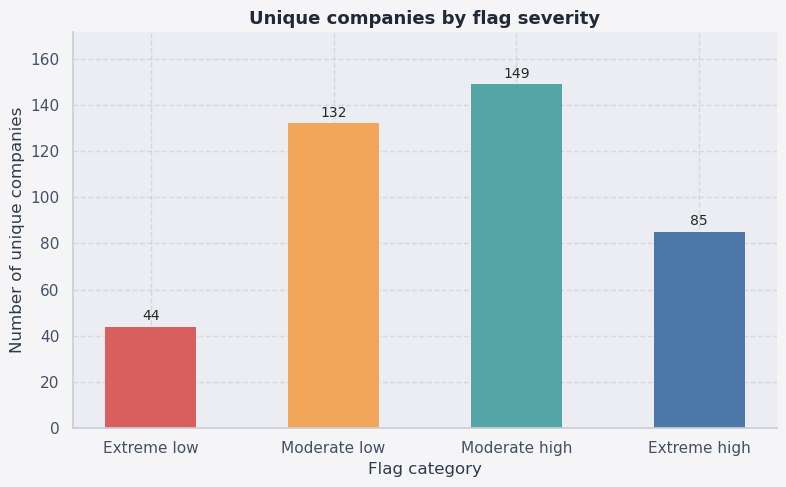

,flag_category,observations,unique_companies
0,Extreme low,140,44
1,Moderate low,601,132
2,Moderate high,657,149
3,Extreme high,359,85


In [43]:
# ── Extreme vs moderate flag breakdown ───────────────────────────────────────
# Four categories per plot:
#   Extreme low  : cost_ratio < EXTREME_LOW_THRESHOLD
#   Moderate low : EXTREME_LOW_THRESHOLD <= cost_ratio < LOW_THRESHOLD
#   Moderate high: HIGH_THRESHOLD < cost_ratio <= EXTREME_HIGH_THRESHOLD
#   Extreme high : cost_ratio > EXTREME_HIGH_THRESHOLD

valid = panel.loc[panel["REVT_valid"] & panel["cost_ratio"].notna()].copy()

valid["flag_category"] = pd.Categorical(
    pd.cut(
        valid["cost_ratio"],
        bins=[-np.inf, EXTREME_LOW_THRESHOLD, LOW_THRESHOLD, HIGH_THRESHOLD, EXTREME_HIGH_THRESHOLD, np.inf],
        labels=["Extreme low", "Moderate low", "Normal", "Moderate high", "Extreme high"],
        right=False,
    ),
    categories=["Extreme low", "Moderate low", "Moderate high", "Extreme high"],
    ordered=True,
)

outside = valid.loc[valid["flag_category"].notna()].copy()

CATEGORY_COLORS = {
    "Extreme low":   PALETTE.get("red",    "#d62728"),
    "Moderate low":  PALETTE.get("orange", "#ff7f0e"),
    "Moderate high": PALETTE.get("teal",   "#17becf"),
    "Extreme high":  PALETTE.get("blue",   "#1f77b4"),
}
CATEGORIES = ["Extreme low", "Moderate low", "Moderate high", "Extreme high"]

# ── Observations plot ─────────────────────────────────────────────────────────
obs_counts = outside["flag_category"].value_counts().reindex(CATEGORIES, fill_value=0)

fig_obs, ax_obs = plt.subplots(figsize=(8, 5))
bars = ax_obs.bar(
    obs_counts.index,
    obs_counts.values,
    color=[CATEGORY_COLORS[c] for c in CATEGORIES],
    width=0.5,
    edgecolor="none",
)
for bar, val in zip(bars, obs_counts.values):
    ax_obs.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + max(obs_counts.values) * 0.01,
        f"{val:,}",
        ha="center", va="bottom", fontsize=10,
    )
ax_obs.set_title("Flagged observations by severity", fontsize=13)
ax_obs.set_xlabel("Flag category")
ax_obs.set_ylabel("Number of observations")
ax_obs.set_ylim(0, max(obs_counts.values) * 1.15)
ax_obs.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
register_figure(fig_obs, "severity_breakdown_observations")
plt.show()
plt.close(fig_obs)

# ── Unique companies plot ─────────────────────────────────────────────────────
firm_counts = (
    outside.groupby("flag_category", observed=True)["Ticker"]
    .nunique()
    .reindex(CATEGORIES, fill_value=0)
)

fig_firms, ax_firms = plt.subplots(figsize=(8, 5))
bars2 = ax_firms.bar(
    firm_counts.index,
    firm_counts.values,
    color=[CATEGORY_COLORS[c] for c in CATEGORIES],
    width=0.5,
    edgecolor="none",
)
for bar, val in zip(bars2, firm_counts.values):
    ax_firms.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + max(firm_counts.values) * 0.01,
        f"{val:,}",
        ha="center", va="bottom", fontsize=10,
    )
ax_firms.set_title("Unique companies by flag severity", fontsize=13)
ax_firms.set_xlabel("Flag category")
ax_firms.set_ylabel("Number of unique companies")
ax_firms.set_ylim(0, max(firm_counts.values) * 1.15)
ax_firms.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
register_figure(fig_firms, "severity_breakdown_unique_companies")
plt.show()
plt.close(fig_firms)

# ── Save table ────────────────────────────────────────────────────────────────
severity_table = pd.DataFrame({
    "flag_category": CATEGORIES,
    "observations": obs_counts.values,
    "unique_companies": firm_counts.values,
})
save_plot_data("severity_breakdown", severity_table)
display(severity_table)


In [ ]:
import os
import json as _json
from pathlib import Path

# ── 1. Classify flag type ────────────────────────────────────────────────────
def classify_flag(row):
    if row["flag_low"] and row["flag_high"]:
        return "Both"
    if row["flag_low"]:
        return "Low"
    if row["flag_high"]:
        return "High"
    return "Not flagged"

flagged = panel.loc[panel["flag_any"]].copy()
flagged["flag_type"] = flagged.apply(classify_flag, axis=1)

# ── 2. Add extreme/moderate severity ────────────────────────────────────────
def classify_severity(row):
    r = row["cost_ratio"]
    if pd.isna(r):
        return "Moderate"
    if r < EXTREME_LOW_THRESHOLD or r > EXTREME_HIGH_THRESHOLD:
        return "Extreme"
    return "Moderate"

flagged["severity"] = flagged.apply(classify_severity, axis=1)

# ── 3. Extract exchange suffix (last two chars of Ticker) ───────────────────
EXCHANGE_ORDER = ["ST",  "IC", "CO", "OL", "HE"]

def extract_suffix(ticker):
    if pd.isna(ticker):
        return "ZZ"  # sort last
    parts = str(ticker).split(".")
    if len(parts) >= 2:
        return parts[-1].upper()
    return "ZZ"

flagged["exchange_suffix"] = flagged["Ticker"].apply(extract_suffix)

def exchange_sort_key(suffix):
    try:
        return EXCHANGE_ORDER.index(suffix)
    except ValueError:
        return len(EXCHANGE_ORDER)

flagged["exchange_order"] = flagged["exchange_suffix"].apply(exchange_sort_key)

# ── 4. Load reviewed tickers from mappings JSON files ───────────────────────
MAPPINGS_DIR = Path("../mappings")
reviewed_tickers = set()

CR_TAGS = {"CR:c", "CR:nc"}

def is_reviewed(json_path):
    """Return True if any variable in the JSON file has notes starting with CR:c or CR:nc."""
    try:
        with open(json_path) as f:
            data = _json.load(f)
        for var in data.get("variables", []):
            notes = var.get("notes", "")
            if isinstance(notes, str):
                # notes may be e.g. "CR:c|low|missing" – check prefix of each | segment
                first_token = notes.strip().split("|")[0].strip()
                if first_token in CR_TAGS:
                    return True
    except Exception:
        pass
    return False

if MAPPINGS_DIR.exists():
    for json_file in MAPPINGS_DIR.rglob("*.json"):
        if is_reviewed(json_file):
            reviewed_tickers.add(json_file.stem)
else:
    print(f"Warning: mappings directory not found at {MAPPINGS_DIR.resolve()}")

print(f"Tickers marked as reviewed (CR:c / CR:nc): {len(reviewed_tickers)}")

# ── 5. Filter out reviewed tickers ──────────────────────────────────────────
# JSON files are named e.g. 'SCAb.ST.json', so stem = 'SCAb.ST' = full Ticker value
flagged = flagged.loc[~flagged["Ticker"].isin(reviewed_tickers)].copy()

print(f"Rows after filtering reviewed tickers: {len(flagged):,}")

# ── 6. Build final sorted table ──────────────────────────────────────────────
show_cols = [
    "Ticker",
    "CompanyName",
    "Year",
    "Exchange",
    "Industry",
    "Sector",
    "REVT",
    "COGS",
    "XSGA_COMPONENTS",
    "TOTAL_COST_PROXY",
    "cost_ratio",
    "flag_type",
    "severity",
]
show_cols = [c for c in show_cols if c in flagged.columns]

flagged_table = (
    flagged
    .sort_values(
        ["exchange_order", "Ticker"],
        ascending=[True, True],
    )
    .reset_index(drop=True)
)[show_cols]

save_plot_data("flagged_table", flagged_table)

# ── 7. Display single scrollable table ──────────────────────────────────────
display(
    HTML(
        "<div style='max-height:600px; overflow-y:auto'>"
        + flagged_table.to_html(index=False, max_rows=None, max_cols=None)
        + "</div>"
    )
)
print(f"Total rows shown: {len(flagged_table):,}")


Tickers marked as reviewed (CR:c / CR:nc): 160
Rows after filtering reviewed tickers: 834


Ticker,CompanyName,Year,Exchange,Industry,Sector,REVT,COGS,XSGA_COMPONENTS,TOTAL_COST_PROXY,cost_ratio,flag_type,severity
NORTHM.CO,North Media A/S,2006,CO,Media & Publishing,Communication Services,1797.98,0.00,0.00,0.00,0.000000,Low,Extreme
SKAKO.CO,Skako A/S,2005,CO,"Machinery, Tools, Heavy Vehicles, Trains & Ships",Industrials,556.87,0.00,0.00,0.00,0.000000,Low,Extreme
SKAKO.CO,Skako A/S,2006,CO,"Machinery, Tools, Heavy Vehicles, Trains & Ships",Industrials,596.16,0.00,0.00,0.00,0.000000,Low,Extreme
SKAKO.CO,Skako A/S,2009,CO,"Machinery, Tools, Heavy Vehicles, Trains & Ships",Industrials,486.11,0.00,0.00,0.00,0.000000,Low,Extreme
SKAKO.CO,Skako A/S,2010,CO,"Machinery, Tools, Heavy Vehicles, Trains & Ships",Industrials,340.17,0.00,0.00,0.00,0.000000,Low,Extreme
TIV.CO,Tivoli A/S,2009,CO,Hotels & Entertainment Services,Consumer Discretionary,728.93,0.00,0.00,0.00,0.000000,Low,Extreme
PRIMOF.CO,Prime Office A/S,2008,CO,Real Estate Operations,Real Estate,9.20,0.10,0.00,0.10,0.010870,Low,Extreme
BO.CO,Bang & Olufsen A/S,2012,CO,"Computers, Phones & Household Electronics",Information Technology,3109.29,0.00,43.10,43.10,0.013862,Low,Extreme
UIE.CO,UIE PLC,2012,CO,Food & Tobacco,Consumer Staples,889.21,0.00,15.76,15.76,0.017724,Low,Extreme
UIE.CO,UIE PLC,2010,CO,Food & Tobacco,Consumer Staples,318.06,0.00,11.76,11.76,0.036974,Low,Extreme


Total rows shown: 834


In [55]:
display(
    HTML(
        flagged_table.to_html(index=False, max_rows=200, max_cols=None)
    )
)


Ticker,CompanyName,Year,Exchange,Industry,Sector,REVT,COGS,XSGA_COMPONENTS,TOTAL_COST_PROXY,cost_ratio,flag_type,severity
ALVO.IC,Alvotech SA,2020,IC,Biotechnology & Medical Research,Health Care,653.57,0.00,1947.91,1947.91,2.980415,High,Extreme
ALVO.IC,Alvotech SA,2023,IC,Biotechnology & Medical Research,Health Care,985.31,1697.25,3032.31,4729.56,4.800073,High,Extreme
ALVO.IC,Alvotech SA,2022,IC,Biotechnology & Medical Research,Health Care,816.79,615.79,3529.42,4145.21,5.075001,High,Extreme
ALVO.IC,Alvotech SA,2021,IC,Biotechnology & Medical Research,Health Care,341.07,0.00,2364.74,2364.74,6.933298,High,Extreme
KALDA.IC,Kaldalon hf,2023,IC,Homebuilding & Construction Supplies,Other,246.98,30.59,18.01,48.60,0.196777,Low,Moderate
KALDA.IC,Kaldalon hf,2024,IC,Homebuilding & Construction Supplies,Other,351.40,47.39,27.52,74.91,0.213176,Low,Moderate
KALDA.IC,Kaldalon hf,2022,IC,Homebuilding & Construction Supplies,Other,122.38,16.67,11.83,28.50,0.232881,Low,Moderate
HEIMAR.IC,Heimar hf,2021,IC,Real Estate Operations,Real Estate,746.54,143.00,36.06,179.06,0.239853,Low,Moderate
HEIMAR.IC,Heimar hf,2022,IC,Real Estate Operations,Real Estate,866.85,165.24,44.49,209.73,0.241945,Low,Moderate
HEIMAR.IC,Heimar hf,2023,IC,Real Estate Operations,Real Estate,1056.08,200.30,55.42,255.72,0.242141,Low,Moderate


In [56]:
display(flagged_table)


,Ticker,CompanyName,Year,Exchange,Industry,Sector,REVT,COGS,XSGA_COMPONENTS,TOTAL_COST_PROXY,cost_ratio,flag_type,severity
0,ALVO.IC,Alvotech SA,2020,IC,Biotechnology & Medical Research,Health Care,653.57,0.00,1947.91,1947.91,2.980415,High,Extreme
1,ALVO.IC,Alvotech SA,2023,IC,Biotechnology & Medical Research,Health Care,985.31,1697.25,3032.31,4729.56,4.800073,High,Extreme
2,ALVO.IC,Alvotech SA,2022,IC,Biotechnology & Medical Research,Health Care,816.79,615.79,3529.42,4145.21,5.075001,High,Extreme
3,ALVO.IC,Alvotech SA,2021,IC,Biotechnology & Medical Research,Health Care,341.07,0.00,2364.74,2364.74,6.933298,High,Extreme
4,KALDA.IC,Kaldalon hf,2023,IC,Homebuilding & Construction Supplies,Other,246.98,30.59,18.01,48.60,0.196777,Low,Moderate
...,...,...,...,...,...,...,...,...,...,...,...,...,...
882,ORIOLA.HE,Oriola Oyj,2009,HE,Pharmaceuticals,Health Care,13694.73,23804.32,0.00,23804.32,1.738210,High,Moderate
883,ORIOLA.HE,Oriola Oyj,2005,HE,Pharmaceuticals,Health Care,10660.47,19030.26,0.00,19030.26,1.785124,High,Moderate
884,ORIOLA.HE,Oriola Oyj,2006,HE,Pharmaceuticals,Health Care,10738.63,19241.06,0.00,19241.06,1.791761,High,Moderate
885,ORIOLA.HE,Oriola Oyj,2007,HE,Pharmaceuticals,Health Care,11033.38,19738.80,956.50,20695.30,1.875699,High,Moderate


In [57]:
low_flagged = flagged_table.loc[flagged_table["flag_type"] == "Low"].reset_index(drop=True)
high_flagged = flagged_table.loc[flagged_table["flag_type"] == "High"].reset_index(drop=True)

print(f"Low flagged rows : {len(low_flagged):,}")
print(f"High flagged rows: {len(high_flagged):,}")

display(low_flagged.head(50))
display(high_flagged.head(50))


Low flagged rows : 407
High flagged rows: 480


,Ticker,CompanyName,Year,Exchange,Industry,Sector,REVT,COGS,XSGA_COMPONENTS,TOTAL_COST_PROXY,cost_ratio,flag_type,severity
0,KALDA.IC,Kaldalon hf,2023,IC,Homebuilding & Construction Supplies,Other,246.98,30.59,18.01,48.60,0.196777,Low,Moderate
1,KALDA.IC,Kaldalon hf,2024,IC,Homebuilding & Construction Supplies,Other,351.40,47.39,27.52,74.91,0.213176,Low,Moderate
2,KALDA.IC,Kaldalon hf,2022,IC,Homebuilding & Construction Supplies,Other,122.38,16.67,11.83,28.50,0.232881,Low,Moderate
3,HEIMAR.IC,Heimar hf,2021,IC,Real Estate Operations,Real Estate,746.54,143.00,36.06,179.06,0.239853,Low,Moderate
4,HEIMAR.IC,Heimar hf,2022,IC,Real Estate Operations,Real Estate,866.85,165.24,44.49,209.73,0.241945,Low,Moderate
5,HEIMAR.IC,Heimar hf,2023,IC,Real Estate Operations,Real Estate,1056.08,200.30,55.42,255.72,0.242141,Low,Moderate
6,HEIMAR.IC,Heimar hf,2024,IC,Real Estate Operations,Real Estate,1156.55,213.90,69.06,282.96,0.244659,Low,Moderate
7,HEIMAR.IC,Heimar hf,2010,IC,Real Estate Operations,Real Estate,111.96,0.00,27.50,27.50,0.245623,Low,Moderate
8,BERAHF.IC,Bera hf.,2024,IC,Beverages,Other,3520.17,897.04,0.00,897.04,0.254829,Low,Moderate
9,REITIR.IC,Reitir fasteignafelag hf,2011,IC,Real Estate Operations,Real Estate,370.34,85.11,16.83,101.94,0.275261,Low,Moderate


,Ticker,CompanyName,Year,Exchange,Industry,Sector,REVT,COGS,XSGA_COMPONENTS,TOTAL_COST_PROXY,cost_ratio,flag_type,severity
0,ALVO.IC,Alvotech SA,2020,IC,Biotechnology & Medical Research,Health Care,653.57,0.00,1947.91,1947.91,2.980415,High,Extreme
1,ALVO.IC,Alvotech SA,2023,IC,Biotechnology & Medical Research,Health Care,985.31,1697.25,3032.31,4729.56,4.800073,High,Extreme
2,ALVO.IC,Alvotech SA,2022,IC,Biotechnology & Medical Research,Health Care,816.79,615.79,3529.42,4145.21,5.075001,High,Extreme
3,ALVO.IC,Alvotech SA,2021,IC,Biotechnology & Medical Research,Health Care,341.07,0.00,2364.74,2364.74,6.933298,High,Extreme
4,SYN.IC,Syn hf,2021,IC,Telecommunications Services,Communication Services,1475.12,994.39,801.92,1796.31,1.217738,High,Moderate
5,SYN.IC,Syn hf,2023,IC,Telecommunications Services,Communication Services,1666.95,1097.02,941.64,2038.66,1.222988,High,Moderate
6,SYN.IC,Syn hf,2018,IC,Telecommunications Services,Communication Services,1567.25,960.25,965.46,1925.71,1.228719,High,Moderate
7,SYN.IC,Syn hf,2020,IC,Telecommunications Services,Communication Services,1458.45,1005.26,805.33,1810.59,1.241448,High,Moderate
8,ICEAIR.IC,Icelandair Group hf,2021,IC,Passenger Transportation Services,Industrials,5027.14,3054.01,3199.49,6253.50,1.243948,High,Moderate
9,SYN.IC,Syn hf,2024,IC,Telecommunications Services,Communication Services,1687.39,1119.13,983.66,2102.79,1.246179,High,Moderate


In [58]:
# Run this cell after all plots above have been created.
# Change PLOT_VERSION in the first cell before re-running if you want a new export folder.
save_all_registered_plots()


Saved 9 plots to: /Users/fredrikfuglerudflugstad/Library/Mobile Documents/com~apple~CloudDocs/Skole/NTNU/Industriell Økonomi og Teknologiledelse/10. Semester/Equity_Quality_Under_Uncertainty/PROF/data_analysis/plots/baseline
 - cost_ratio_distribution.png
 - flagged_observations_by_exchange.png
 - unique_flagged_firms_by_exchange.png
 - flagged_observations_by_sector.png
 - unique_flagged_firms_by_sector.png
 - flag_summary_observations.png
 - flag_summary_unique_companies.png
 - severity_breakdown_observations.png
 - severity_breakdown_unique_companies.png
